In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.direct.targeted import CrossEntropyConfidence
from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_mnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [3]:
from utils.transforms.apply import grid_resample_border,grid_resample_reflection

In [4]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [5]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [6]:
x=next(iter(test_loader_transformed))[0]

In [7]:
batch_size = next(iter(train_loader))[0].shape[0]


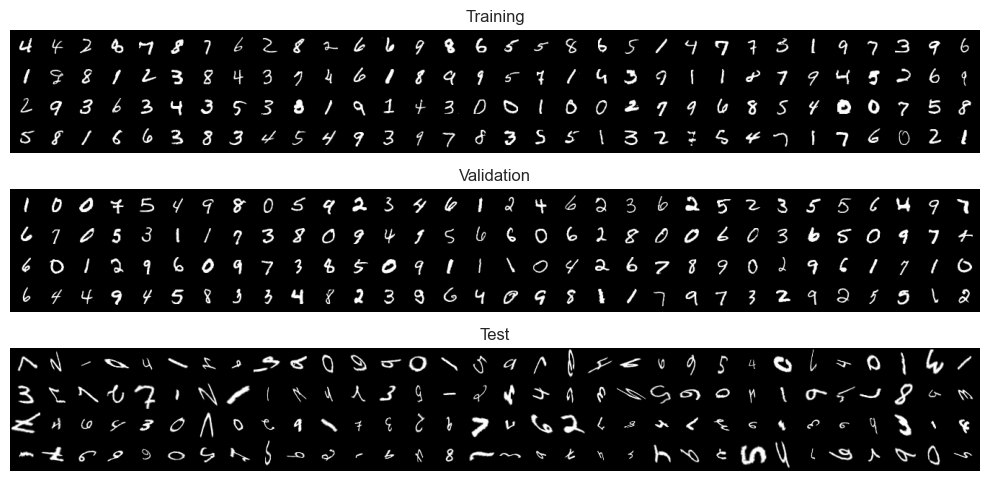

In [8]:
from utils.eval.vis import vis_dataset

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [9]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparision_over_budget")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [10]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [11]:
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [12]:
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)

{'accuracy': 0.37689998745918274, 'f2_macro': 0.37094762921333313, 'f2_micro': 0.37689998745918274, 'f2_weighted': 0.3730011582374573}


In [13]:
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.9955999851226807, 'f2_macro': 0.9955340027809143, 'f2_micro': 0.9955999851226807, 'f2_weighted': 0.9955984354019165}


In [14]:
res = evaluate_base_model(model, val_loader, device)
print(res)

{'accuracy': 0.9950000047683716, 'f2_macro': 0.9949420094490051, 'f2_micro': 0.9950000047683716, 'f2_weighted': 0.9949992895126343}


In [15]:
class TensorGeometricModelUnwrapper(torch.nn.Module):
    """
    Wrapper for a torch_geometric model that receives a tuple of (pos, y) as input and creates
    a Data object from it that is passed to the model.
    """
    def __init__(self):
        super(TensorGeometricModelUnwrapper, self).__init__()

    def forward(self, data):
        # pos and y are batched tensors from a DataLoader
        # need to reconstruct the original Data objects for torch_geometric models

        pos = data.pos
        batch = data.batch
        #split pos into individual tensors based on batch
        pos_list = torch.split(pos, torch.bincount(batch).tolist())
        return torch.stack(pos_list)

In [16]:
#chek if data is iamge data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [17]:
from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).to(device)

In [18]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 4, num_classes=None, num_rotations=8)

In [19]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
random_search = SHGO(initial_samples=120, local_max_steps=0)

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search, evaluate_confidence_and_search, \
    ITSWRAPPER


In [20]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.8205999732017517,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.8165746927261353,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8205999732017517,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8181073665618896,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8205999732017517,
   'f2_macro': 0.8165746927261353,
   'f2_micro': 0.8205999732017517,
   'f2_weighted': 0.8181073665618896,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [21]:
model.to(device).eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [22]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [23]:
if "modelnet10" in dataset:
    for init_method in ["individual","sobol"]:
        print(f"Testing init method: {init_method}")
        import torch
        import kornia
        import matplotlib.pyplot as plt
        import numpy as np
        from mpl_toolkits.mplot3d import Axes3D
        from utils.affine_transforms import AffineTransformations3D
        from utils.transform_sequence import TransformSequence
        from scipy import stats

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


        # Save original init method and temporarily switch to "individual"
        original_init = transform_seq.init_method
        transform_seq.init_method = init_method

        # --- 1. Generate your matrices ---
        zw = transform_seq.initial_param(1280)
        transform_seq.init_method = original_init
        matrix = transform_seq(zw)

        # --- 2. Extract rotation submatrices ---
        R = matrix[:, :3, :3]  # [N, 3, 3]

        # --- 3. Convert to axis–angle representation ---
        rotvec = kornia.geometry.conversions.rotation_matrix_to_axis_angle(R)  # [N, 3]
        theta = torch.linalg.norm(rotvec, dim=1)
        axis = torch.nn.functional.normalize(rotvec, dim=1)

        axis_np = axis.cpu().numpy()
        theta_np = theta.cpu().numpy()

        # --- 4. Quantitative checks ---

        # (a) Axis uniformity
        mean_axis = axis_np.mean(axis=0)
        spherical_var = 1 - np.linalg.norm(mean_axis)
        print("Axis mean vector:", mean_axis)
        print("Spherical variance (1 - |mean|):", spherical_var)

        # (b) Rotation angle
        sample_mean = np.mean(theta_np)
        theory_mean = np.pi/2 + 2/np.pi  # Correct expected mean for uniform SO(3)
        print(f"Sample mean rotation angle (rad): {sample_mean:.4f}")
        print(f"Theoretical mean rotation angle (rad): {theory_mean:.4f}")

        # (c) Kolmogorov–Smirnov test against theoretical CDF
        def F_theta(t):
            # CDF for p(theta) ∝ sin²(theta/2)
            return (t - np.sin(t)) / np.pi

        ks_stat, pval = stats.kstest(theta_np, F_theta)
        print(f"KS statistic: {ks_stat:.4f}, p-value: {pval:.4f}")

        # --- 5. Visualization ---

        fig = plt.figure(figsize=(12, 5))

        # Angle histogram
        plt.subplot(1, 2, 1)
        plt.hist(theta_np, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
        t_grid = np.linspace(0, np.pi, 200)
        plt.plot(t_grid, (2/np.pi) * np.sin(t_grid/2)**2, 'r-', lw=2, label='theoretical pdf')
        plt.xlabel("Rotation angle (radians)")
        plt.ylabel("Density")
        plt.title("Rotation Angle Distribution")
        plt.legend()

        # 3D scatter of axes
        ax = fig.add_subplot(1, 2, 2, projection='3d')
        ax.scatter(axis_np[:, 0], axis_np[:, 1], axis_np[:, 2], s=8, alpha=0.7)
        # Draw reference sphere
        u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
        x = np.cos(u)*np.sin(v)
        y = np.sin(u)*np.sin(v)
        z = np.cos(v)
        ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)
        ax.set_box_aspect([1,1,1])
        ax.set_title("Rotation Axes on Unit Sphere")

        plt.tight_layout()
        plt.show()


In [24]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = utils.augments.build_default_augmentations()
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf2 = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_energy_conf_best.safetensors
Model has non-negative constraint: False


In [25]:
model.to(device).eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [26]:
from model.pointnet_plus import SAModule
def set_deterministic_fps(model, random_start=False):
    for module in model.modules():
        if isinstance(module, SAModule):
            module.random_start = random_start
            print(f"Set random_start={random_start} for {module.__class__.__name__}")

set_deterministic_fps(model)
set_deterministic_fps(energy_model2)

In [27]:
energy_conf2.to(device).eval()



problem_energy2 = TransformationProblem(energy_conf2, transform_seq,                                              consolidate_method="consolidate_simple")



In [28]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy2,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.9746999740600586,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9744691848754883,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9746999740600586,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.974661111831665,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9746999740600586,
   'f2_macro': 0.9744691848754883,
   'f2_micro': 0.9746999740600586,
   'f2_weighted': 0.974661111831665,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [29]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [30]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))

dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=layer_io, flatten=True)




from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="masked",k=1)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.to(device)

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [31]:
#benchmark model and dual output model

In [32]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed"), show_progress=True,
    repeats=1,overwrite=False)

{'repeats': 1,
 'accuracy_mean': 0.8805999755859375,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.8789754509925842,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8805999755859375,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8800798654556274,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8805999755859375,
   'f2_macro': 0.8789754509925842,
   'f2_micro': 0.8805999755859375,
   'f2_weighted': 0.8800798654556274,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [33]:
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})


In [34]:
transfomr_seq_reflection = get_transformation_sequence_images(
                name="biggermnist_reflections",
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).to(device)

In [35]:
from confidence.base_confidence import ConfidenceModule


class CrossEntropyConfidence(ConfidenceModule):
    """
    Computes confidence as the negative cross‐entropy loss between logits and labels.
    Requires y to be provided.
    Basically cheating but can be used for finding points of high confidence in the correct class.
    """

    def __init__(self,y_override=None):
        super(CrossEntropyConfidence, self).__init__()
        self.y_override = y_override

    def forward(self, logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        logits: (*batch_dims, num_classes)
        y: (*batch_dims,) integer class labels

        Returns:
            confidence: (*batch_dims,) = -cross_entropy(logits, y)
        """
        if y is None:
            raise ValueError("CrossEntropyConfidence requires target labels y.")

        if self.y_override is not None:
            #set the tensors element to y_override
            y = torch.full_like(y, self.y_override, dtype=torch.long)
        # reduction='none' gives per-sample loss, then negate
        loss = torch.nn.functional.cross_entropy(logits, y, reduction='none')
        return -loss

In [36]:
from confidence.control.split import TrueLabelSplitConfidence

conf_split_pretrained = TrueLabelSplitConfidence(nn_pytorch_pretrained, CrossEntropyConfidence(7), mult=False,a=10,b=1)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_guided = TransformationProblem(conf_mod_nn_pytorch_pretrained, transfomr_seq_reflection,consolidate_method="consolidate_simple")
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [37]:
problem_nn_pytorch_pretrained_reflection = TransformationProblem(conf_mod_nn_pytorch_pretrained, transfomr_seq_reflection,
                                                      consolidate_method="consolidate_simple")

In [38]:
figure_path = os.path.join(current_path,"experiment_files","export","fig","examples",dataset,transform_name)
os.makedirs(figure_path, exist_ok=True)


=== Attempt 1 | Seed = 937367289 ===
Prediction: 7
=== Attack succeeded! ===
Finished.


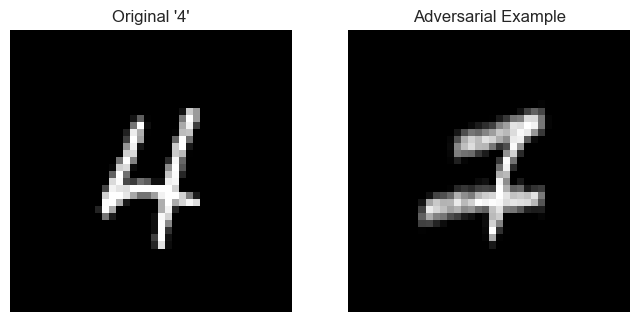

In [39]:
import random
import numpy as np
import torch

attack_log = {
    "attempts": [],
    "success": None,
}

max_attempts = 500
attempt = 0


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

opt_huge = SHGO(initial_samples=200, local_runs=5, local_max_steps=5,local_opt_kwargs={"lr":0.1})


while attempt < max_attempts:
    attempt += 1

    # -------------------------------
    # Generate & set seed for this attempt
    # -------------------------------
    seed = random.randint(0, 2 ** 31 - 1)

    seed = 937367289
    set_global_seed(seed)

    print(f"\n=== Attempt {attempt} | Seed = {seed} ===")

    # Save attempt info
    attempt_record = {
        "attempt": attempt,
        "seed": seed,
        "prediction": None,
    }

    # -------------------------------
    # Pick a fresh "4"
    # -------------------------------
    found =0

    for x, y in test_loader:
        idxs = (y == 4).nonzero(as_tuple=True)[0]
        if len(idxs) > 0:
            x_4 = x[idxs[0:1]].to(device)
            y_4 = y[idxs[0:1]].to(device)
            found +=1
            if found >=6:
                break

    # -------------------------------
    # Random initial params
    # (seed already set globally)
    # -------------------------------
    p_random = transfomr_seq_reflection.initial_param(1)
    x_init = transfomr_seq_reflection.transform(x_4, p_random)
    x_init = torch.clamp(x_init, 0, 1)

    # -------------------------------
    # Run SHGO optimization
    # -------------------------------
    res = opt_huge.optimize(
        problem_guided, x_init, y_4,
        verbose=True
    )
    p = res[0]
    x_adv = transfomr_seq_reflection.transform(x_init, p)
    x_adv = torch.clamp(x_adv, 0, 1)

    #save both original and adv images


    # -------------------------------
    # Check prediction
    # -------------------------------
    pred = model(x_adv).argmax(dim=-1).item()
    attempt_record["prediction"] = pred
    print("Prediction:", pred)
    torchvision.utils.save_image(x_4, os.path.join(figure_path,f"attempt_{attempt}_original_4.png"))
    torchvision.utils.save_image(x_adv, os.path.join(figure_path,f"attempt_{attempt}_adversarial_example.png"))


    if pred == 7:
        print("=== Attack succeeded! ===")
        attack_log["success"] = True
        attack_log["attempts"].append(attempt_record)
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.title("Original '4'")
        plt.imshow(x_4[0].cpu().squeeze(), cmap='gray')
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.title("Adversarial Example")
        plt.imshow(x_adv[0].cpu().squeeze(), cmap='gray')
        plt.axis('off')
        break

    attack_log["attempts"].append(attempt_record)
    #save images



print("Finished.")
